In [ ]:
pip install torch torchvision torchaudio opencv-python scikit-learn matplotlib seaborn numpy Pillow

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from PIL import Image
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             precision_score,
                             recall_score,
                             f1_score,
                             accuracy_score)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

print('PyTorch version:', torch.__version__)
print('CUDA available :', torch.cuda.is_available())
print('All libraries imported successfully.')

# Use GPU if available, otherwise fall back to CPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device   :', DEVICE)

PyTorch version: 2.11.0+cpu
CUDA available : False
All libraries imported successfully.
Using device   : cpu


In [2]:
# Set the path to your faces folder
DATASET_PATH = 'faces'

# Target image size (width, height) for resizing
IMG_SIZE = (128, 128)

# Supported image file extensions
VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp')


In [3]:
raw_images = []   # Will hold numpy arrays of pixel data
labels     = []   # Will hold student ID strings
bad_files  = []   # Will track files that cannot be loaded

student_folders = sorted(os.listdir(DATASET_PATH))

for student_id in student_folders:
    folder_path = os.path.join(DATASET_PATH, student_id)
    if not os.path.isdir(folder_path):
        continue  # Skip any files at the top level
    for filename in sorted(os.listdir(folder_path)):
        if not filename.lower().endswith(VALID_EXTENSIONS):
            continue  # Skip non-image files
        file_path = os.path.join(folder_path, filename)
        img = cv2.imread(file_path)
        if img is None:
            bad_files.append(file_path)
            print(f'WARNING: Could not load {file_path}')
            continue
        raw_images.append(img)
        labels.append(student_id)

print(f'Total images loaded : {len(raw_images)}')
print(f'Total students found: {len(student_folders)}')
print(f'Corrupted/unreadable files: {len(bad_files)}')


Total images loaded : 143
Total students found: 39
Corrupted/unreadable files: 0


Images per student:
  STU001: 4 images
  STU004: 4 images
  STU006: 4 images
  STU007: 4 images
  STU010: 4 images
  STU011: 4 images
  STU012: 4 images
  STU013: 4 images
  STU016: 4 images
  STU017: 4 images
  STU018: 4 images
  STU019: 4 images
  STU020: 4 images
  STU021: 4 images
  STU022: 4 images
  STU023: 4 images
  STU026: 8 images
  STU027: 4 images
  STU028: 4 images
  STU031: 4 images
  STU032: 4 images
  STU033: 4 images
  STU034: 4 images
  STU035: 4 images
  STU038: 4 images
  STU039: 4 images
  STU041: 4 images
  STU042: 4 images
  STU043: 4 images
  STU047: 4 images
  STU058: 4 images
  STU060: 4 images
  STU065: 4 images
  STU070: 3 images
  STU071: 4 images


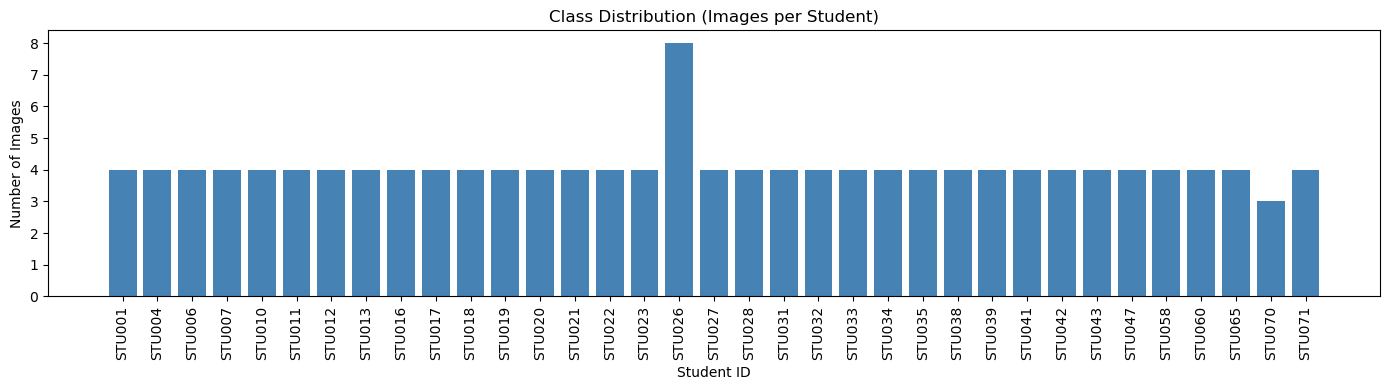

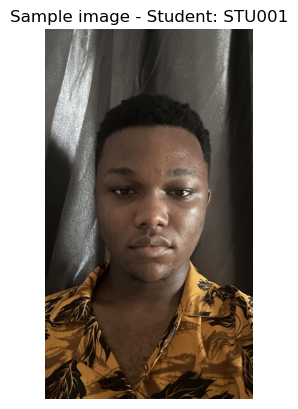

Unique image shapes found: {(1280, 960, 3), (1280, 975, 3), (1280, 1160, 3), (2513, 2380, 3), (1080, 707, 3), (1052, 780, 3), (2560, 1920, 3), (303, 284, 3), (405, 404, 3), (1280, 719, 3), (1080, 810, 3), (2560, 1440, 3), (960, 540, 3), (1280, 1047, 3), (4080, 3060, 3), (1280, 1280, 3), (2562, 2573, 3), (1080, 812, 3), (1280, 983, 3), (1280, 1238, 3), (1600, 1200, 3), (1280, 954, 3), (2248, 2202, 3), (343, 339, 3), (1280, 1090, 3), (1261, 928, 3), (1280, 1070, 3), (359, 376, 3), (3088, 1737, 3), (2314, 2314, 3)}


In [4]:
# Count images per student
label_counts = Counter(labels)
print('Images per student:')
for student, count in sorted(label_counts.items()):
    print(f'  {student}: {count} images')

# Plot the class distribution
plt.figure(figsize=(14, 4))
plt.bar(label_counts.keys(), label_counts.values(), color='steelblue')
plt.xlabel('Student ID')
plt.ylabel('Number of Images')
plt.title('Class Distribution (Images per Student)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Show a sample image from the first student
sample_img = cv2.cvtColor(raw_images[0], cv2.COLOR_BGR2RGB)
plt.imshow(sample_img)
plt.title(f'Sample image - Student: {labels[0]}')
plt.axis('off')
plt.show()

# Check original image sizes
shapes = [img.shape for img in raw_images]
unique_shapes = set(shapes)
print('Unique image shapes found:', unique_shapes)


In [5]:
MIN_DIM = 30  # Minimum acceptable pixel dimension (width or height)

cleaned_images = []
cleaned_labels = []
removed_count  = 0

for img, label in zip(raw_images, labels):
    h, w = img.shape[:2]
    if h < MIN_DIM or w < MIN_DIM:
        removed_count += 1
        print(f'Removed tiny image ({w}x{h}) for student {label}')
        continue
    cleaned_images.append(img)
    cleaned_labels.append(label)

print(f'Images removed (too small): {removed_count}')
print(f'Images remaining          : {len(cleaned_images)}')



Images removed (too small): 0
Images remaining          : 143


In [6]:
def average_hash(img, hash_size=8):
    """Compute a simple average hash for an image."""
    gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (hash_size, hash_size))
    mean_val = resized.mean()
    return tuple((resized > mean_val).flatten().astype(int))

seen_hashes  = set()
deduped_images = []
deduped_labels = []
dup_count = 0

for img, label in zip(cleaned_images, cleaned_labels):
    h = average_hash(img)
    if h in seen_hashes:
        dup_count += 1
        continue
    seen_hashes.add(h)
    deduped_images.append(img)
    deduped_labels.append(label)

print(f'Duplicate images removed  : {dup_count}')
print(f'Images after deduplication: {len(deduped_images)}')



Duplicate images removed  : 2
Images after deduplication: 141


In [7]:
resized_images = []
for img in deduped_images:
    resized = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
    resized_images.append(resized)

print(f'All images resized to {IMG_SIZE[0]}x{IMG_SIZE[1]} pixels.')
print(f'Sample shape: {resized_images[0].shape}')


All images resized to 128x128 pixels.
Sample shape: (128, 128, 3)


In [8]:
rgb_images = []
for img in resized_images:
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    rgb_images.append(rgb)

print('Color channels converted from BGR to RGB.')


Color channels converted from BGR to RGB.


In [9]:
X     = np.array(rgb_images, dtype=np.float32)   # Shape: (N, 128, 128, 3)
y_raw = np.array(deduped_labels)

print('Image array shape:', X.shape)
print('Labels array shape:', y_raw.shape)


Image array shape: (141, 128, 128, 3)
Labels array shape: (141,)


In [10]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)  # e.g. STU001 -> 0, STU002 -> 1

NUM_CLASSES = len(le.classes_)
print(f'Number of unique students (classes): {NUM_CLASSES}')
print('Class mapping (first 5):',
      dict(zip(le.classes_[:5], range(5))))
print('Labels are integer-encoded — no one-hot encoding needed for PyTorch.')


Number of unique students (classes): 35
Class mapping (first 5): {np.str_('STU001'): 0, np.str_('STU004'): 1, np.str_('STU006'): 2, np.str_('STU007'): 3, np.str_('STU010'): 4}
Labels are integer-encoded — no one-hot encoding needed for PyTorch.


In [11]:
X_scaled = X / 255.0
print('Pixel value range before scaling: 0 to 255')
print(f'Pixel value range after scaling: {X_scaled.min():.4f} to {X_scaled.max():.4f}')


Pixel value range before scaling: 0 to 255
Pixel value range after scaling: 0.0000 to 1.0000


In [12]:
TEST_SIZE   = 0.25   # 25% of data goes to the test set
RANDOM_SEED = 45    # For reproducibility

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y_encoded   # Keep class proportions equal in both splits
)

print(f'Training set size: {X_train.shape[0]} images')
print(f'Test set size    : {X_test.shape[0]} images')


Training set size: 105 images
Test set size    : 36 images


In [13]:
class FaceDataset(Dataset):
    """
    Custom PyTorch Dataset for student face images.
    - images : numpy array of shape (N, H, W, 3), float32, range [0,1]
    - labels : numpy array of integer class indices
    - transform: torchvision transform pipeline (augmentation for training,
                 plain ToTensor for testing)
    """
    def __init__(self, images, labels, transform=None):
        self.images    = images
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Convert numpy float32 [0,1] -> PIL Image (required by torchvision)
        img_uint8 = (self.images[idx] * 255).astype(np.uint8)
        img_pil   = Image.fromarray(img_uint8)

        if self.transform:
            img_tensor = self.transform(img_pil)
        else:
            img_tensor = transforms.ToTensor()(img_pil)

        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img_tensor, label


In [14]:
train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=15),         # Rotate up to 15 degrees
    transforms.RandomHorizontalFlip(p=0.5),        # Mirror left-right 50% of the time
    transforms.RandomAffine(degrees=0,
                            translate=(0.1, 0.1)), # Shift up to 10% horizontally/vertically
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.1),          # Vary brightness and contrast
    transforms.RandomResizedCrop(size=(128, 128),
                                 scale=(0.9, 1.0)),# Slight zoom
    transforms.ToTensor(),                         # Convert PIL -> (C, H, W) float tensor
])

test_transform = transforms.Compose([
    transforms.ToTensor(),                         # No augmentation on test data
])

print('Transforms defined.')
print('Training augmentations: rotation, flip, shift, brightness, zoom')


Transforms defined.
Training augmentations: rotation, flip, shift, brightness, zoom


In [15]:
BATCH_SIZE = 16

train_dataset = FaceDataset(X_train, y_train, transform=train_transform)
test_dataset  = FaceDataset(X_test,  y_test,  transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)

print(f'Training samples  : {len(train_dataset)}')
print(f'Test samples      : {len(test_dataset)}')
print(f'Training batches  : {len(train_loader)}')
print(f'Test batches      : {len(test_loader)}')


Training samples  : 105
Test samples      : 36
Training batches  : 7
Test batches      : 3


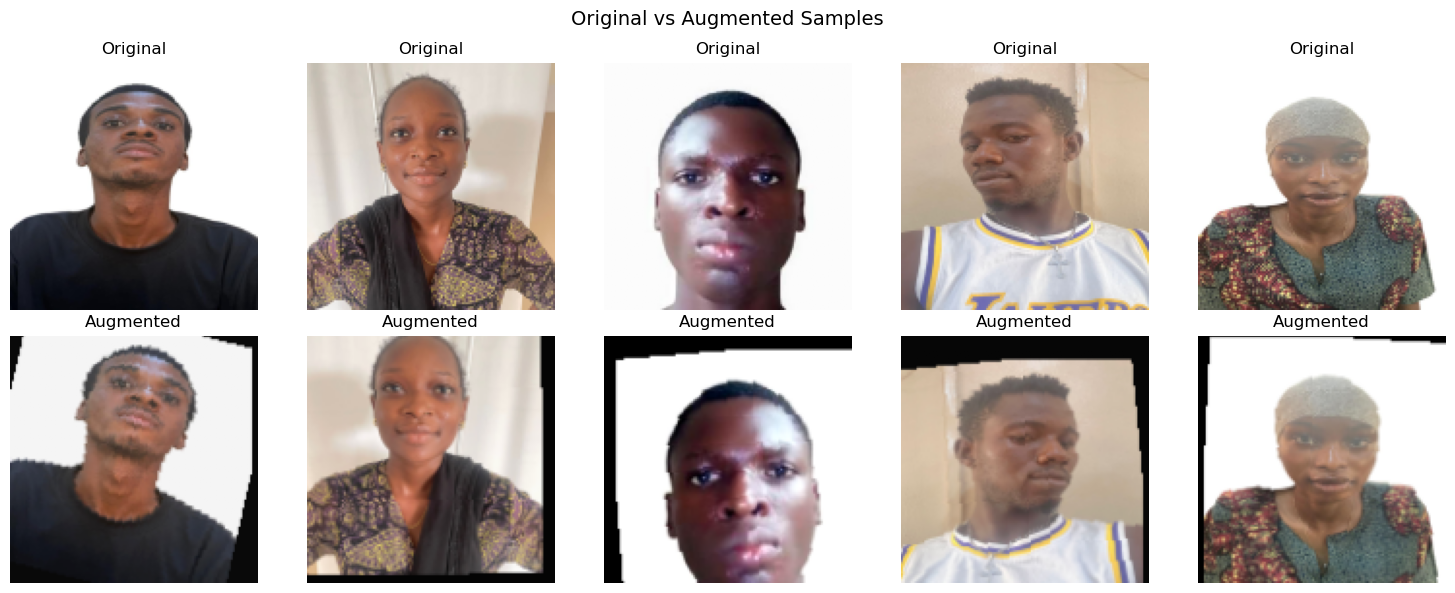

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Original vs Augmented Samples', fontsize=14)

# Show 5 originals in row 1
for i in range(5):
    axes[0, i].imshow(X_train[i])
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')

# Show 5 augmented versions in row 2 (apply transform manually)
for i in range(5):
    img_uint8  = (X_train[i] * 255).astype(np.uint8)
    img_pil    = Image.fromarray(img_uint8)
    aug_tensor = train_transform(img_pil)
    aug_np     = aug_tensor.permute(1, 2, 0).numpy()  # (C,H,W) -> (H,W,C)
    aug_np     = np.clip(aug_np, 0, 1)
    axes[1, i].imshow(aug_np)
    axes[1, i].set_title('Augmented')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


In [17]:
class FaceCNN(nn.Module):
    """
    CNN for student face recognition.
    Architecture:
    - 3 convolutional blocks (Conv2d + BatchNorm + MaxPool + Dropout)
    - Global Average Pooling to reduce parameters
    - 2 fully connected (Linear) layers with Dropout
    - Softmax output (via CrossEntropyLoss during training)
    """
    def __init__(self, num_classes):
        super(FaceCNN, self).__init__()

        # Block 1: detect low-level features (edges, colour patches)
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=0.25)
        )

        # Block 2: detect mid-level features (textures, curves)
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=0.25)
        )

        # Block 3: detect high-level features (face parts)
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=0.40)
        )

        # Global Average Pooling reduces (N, 128, H, W) -> (N, 128, 1, 1)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # Fully connected classifier
        self.classifier = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(128, num_classes)
            # No Softmax here — CrossEntropyLoss applies it internally
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)  # Flatten: (N, 128, 1, 1) -> (N, 128)
        x = self.classifier(x)
        return x

model = FaceCNN(num_classes=NUM_CLASSES).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {total_params:,}')


FaceCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.25, inplace=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False

In [18]:
criterion = nn.CrossEntropyLoss()   # Works with integer class labels directly

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4    # L2 regularisation (equivalent to kernel_regularizer=l2)
)

print('Loss function : CrossEntropyLoss')
print('Optimiser     : Adam (lr=0.001, weight_decay=1e-4)')
print('Model moved to:', DEVICE)


Loss function : CrossEntropyLoss
Optimiser     : Adam (lr=0.001, weight_decay=1e-4)
Model moved to: cpu


In [19]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Run one full pass over the training data."""
    model.train()  # Enable dropout and batchnorm in training mode
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # Clear gradients from previous step
        outputs = model(images)        # Forward pass
        loss    = criterion(outputs, labels)  # Compute loss
        loss.backward()                # Backpropagation
        optimizer.step()               # Update weights

        total_loss += loss.item() * images.size(0)
        _, preds   = torch.max(outputs, 1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


def evaluate(model, loader, criterion, device):
    """Evaluate model on a DataLoader without updating weights."""
    model.eval()  # Disable dropout, use running stats in BatchNorm
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():  # No gradient computation needed during evaluation
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, preds   = torch.max(outputs, 1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

print('Training helper functions defined.')


Training helper functions defined.


In [20]:
EPOCHS      = 80
PATIENCE    = 10          # Stop if val_loss doesn't improve for 10 epochs
SAVE_PATH   = 'best_face_model.pth'

best_val_loss  = float('inf')
epochs_no_imp  = 0
best_weights   = None

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader,
                                            criterion, optimizer, DEVICE)
    val_loss,   val_acc   = evaluate(model, test_loader, criterion, DEVICE)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch:3d}/{EPOCHS} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_imp = 0
        best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
        torch.save(model.state_dict(), SAVE_PATH)
        print(f'  --> Best model saved (val_loss={best_val_loss:.4f})')
    else:
        epochs_no_imp += 1
        if epochs_no_imp >= PATIENCE:
            print(f'\nEarly stopping triggered at epoch {epoch}.')
            break

# Restore best weights into the model
model.load_state_dict(best_weights)
print('\nTraining complete. Best weights restored.')


Epoch   1/80 | Train Loss: 3.5776 Acc: 0.0286 | Val Loss: 3.5575 Acc: 0.0278
  --> Best model saved (val_loss=3.5575)
Epoch   2/80 | Train Loss: 3.5739 Acc: 0.0286 | Val Loss: 3.5556 Acc: 0.0278
  --> Best model saved (val_loss=3.5556)
Epoch   3/80 | Train Loss: 3.5446 Acc: 0.0190 | Val Loss: 3.5526 Acc: 0.0278
  --> Best model saved (val_loss=3.5526)
Epoch   4/80 | Train Loss: 3.5164 Acc: 0.0286 | Val Loss: 3.5468 Acc: 0.0556
  --> Best model saved (val_loss=3.5468)
Epoch   5/80 | Train Loss: 3.5483 Acc: 0.0095 | Val Loss: 3.5396 Acc: 0.0556
  --> Best model saved (val_loss=3.5396)
Epoch   6/80 | Train Loss: 3.5213 Acc: 0.0286 | Val Loss: 3.5279 Acc: 0.0556
  --> Best model saved (val_loss=3.5279)
Epoch   7/80 | Train Loss: 3.5131 Acc: 0.0667 | Val Loss: 3.5162 Acc: 0.0556
  --> Best model saved (val_loss=3.5162)
Epoch   8/80 | Train Loss: 3.5101 Acc: 0.0762 | Val Loss: 3.5035 Acc: 0.0556
  --> Best model saved (val_loss=3.5035)
Epoch   9/80 | Train Loss: 3.5117 Acc: 0.0476 | Val Loss

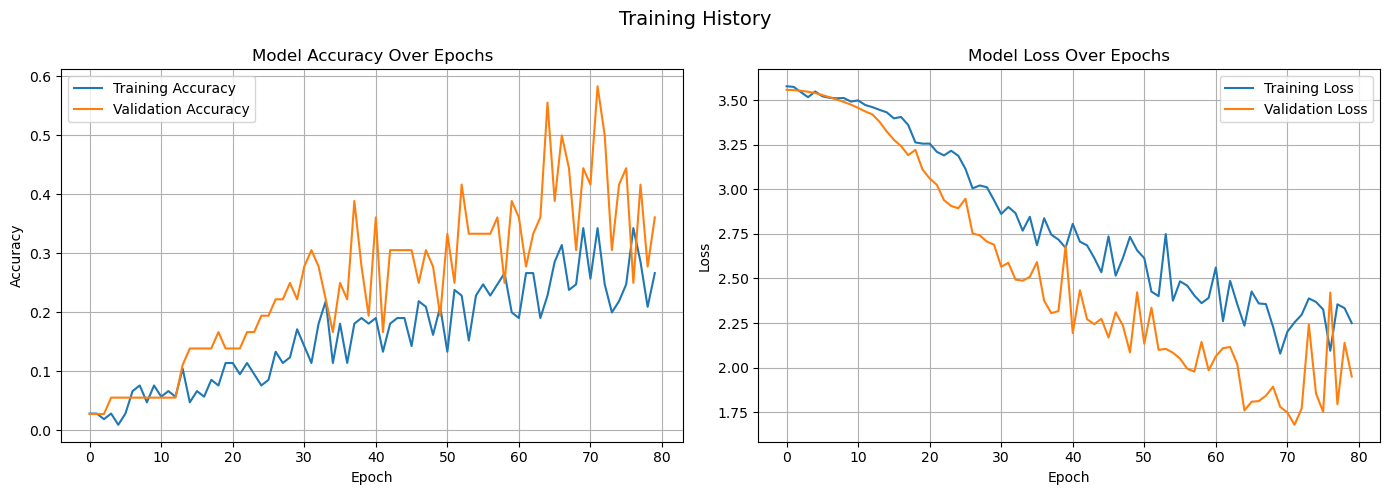

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history['train_acc'], label='Training Accuracy')
ax1.plot(history['val_acc'],   label='Validation Accuracy')
ax1.set_title('Model Accuracy Over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history['train_loss'], label='Training Loss')
ax2.plot(history['val_loss'],   label='Validation Loss')
ax2.set_title('Model Loss Over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.suptitle('Training History', fontsize=14)
plt.tight_layout()
plt.show()


In [22]:
model.eval()
all_preds = []
all_true  = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.numpy())

y_pred_encoded = np.array(all_preds)
y_test_encoded = np.array(all_true)
print(f'Predictions generated for {len(y_pred_encoded)} test images.')


Predictions generated for 36 test images.


In [23]:
acc  = accuracy_score(y_test_encoded, y_pred_encoded)
prec = precision_score(y_test_encoded, y_pred_encoded, average='weighted', zero_division=0)
rec  = recall_score(y_test_encoded,    y_pred_encoded, average='weighted', zero_division=0)
f1   = f1_score(y_test_encoded,        y_pred_encoded, average='weighted', zero_division=0)

print('=' * 45)
print('MODEL EVALUATION RESULTS')
print('=' * 45)
print(f'Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1-Score  : {f1:.4f}')
print('=' * 45)


C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The numbe

MODEL EVALUATION RESULTS
Accuracy  : 0.5833  (58.33%)
Precision : 0.4491
Recall    : 0.5833
F1-Score  : 0.4907


C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is g

In [24]:
report = classification_report(
    y_test_encoded,
    y_pred_encoded,
    target_names=le.classes_,
    zero_division=0
)
print('CLASSIFICATION REPORT')
print(report)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      STU001       1.00      1.00      1.00         1
      STU004       0.00      0.00      0.00         1
      STU006       1.00      1.00      1.00         1
      STU007       0.00      0.00      0.00         1
      STU010       0.00      0.00      0.00         1
      STU011       1.00      1.00      1.00         1
      STU012       0.00      0.00      0.00         1
      STU013       1.00      1.00      1.00         1
      STU016       1.00      1.00      1.00         1
      STU017       1.00      1.00      1.00         1
      STU018       0.00      0.00      0.00         1
      STU019       0.50      1.00      0.67         1
      STU020       1.00      1.00      1.00         1
      STU021       1.00      1.00      1.00         1
      STU022       1.00      1.00      1.00         1
      STU023       0.33      1.00      0.50         1
      STU026       0.00      0.00      0.00         2
     

C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is g

C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is g

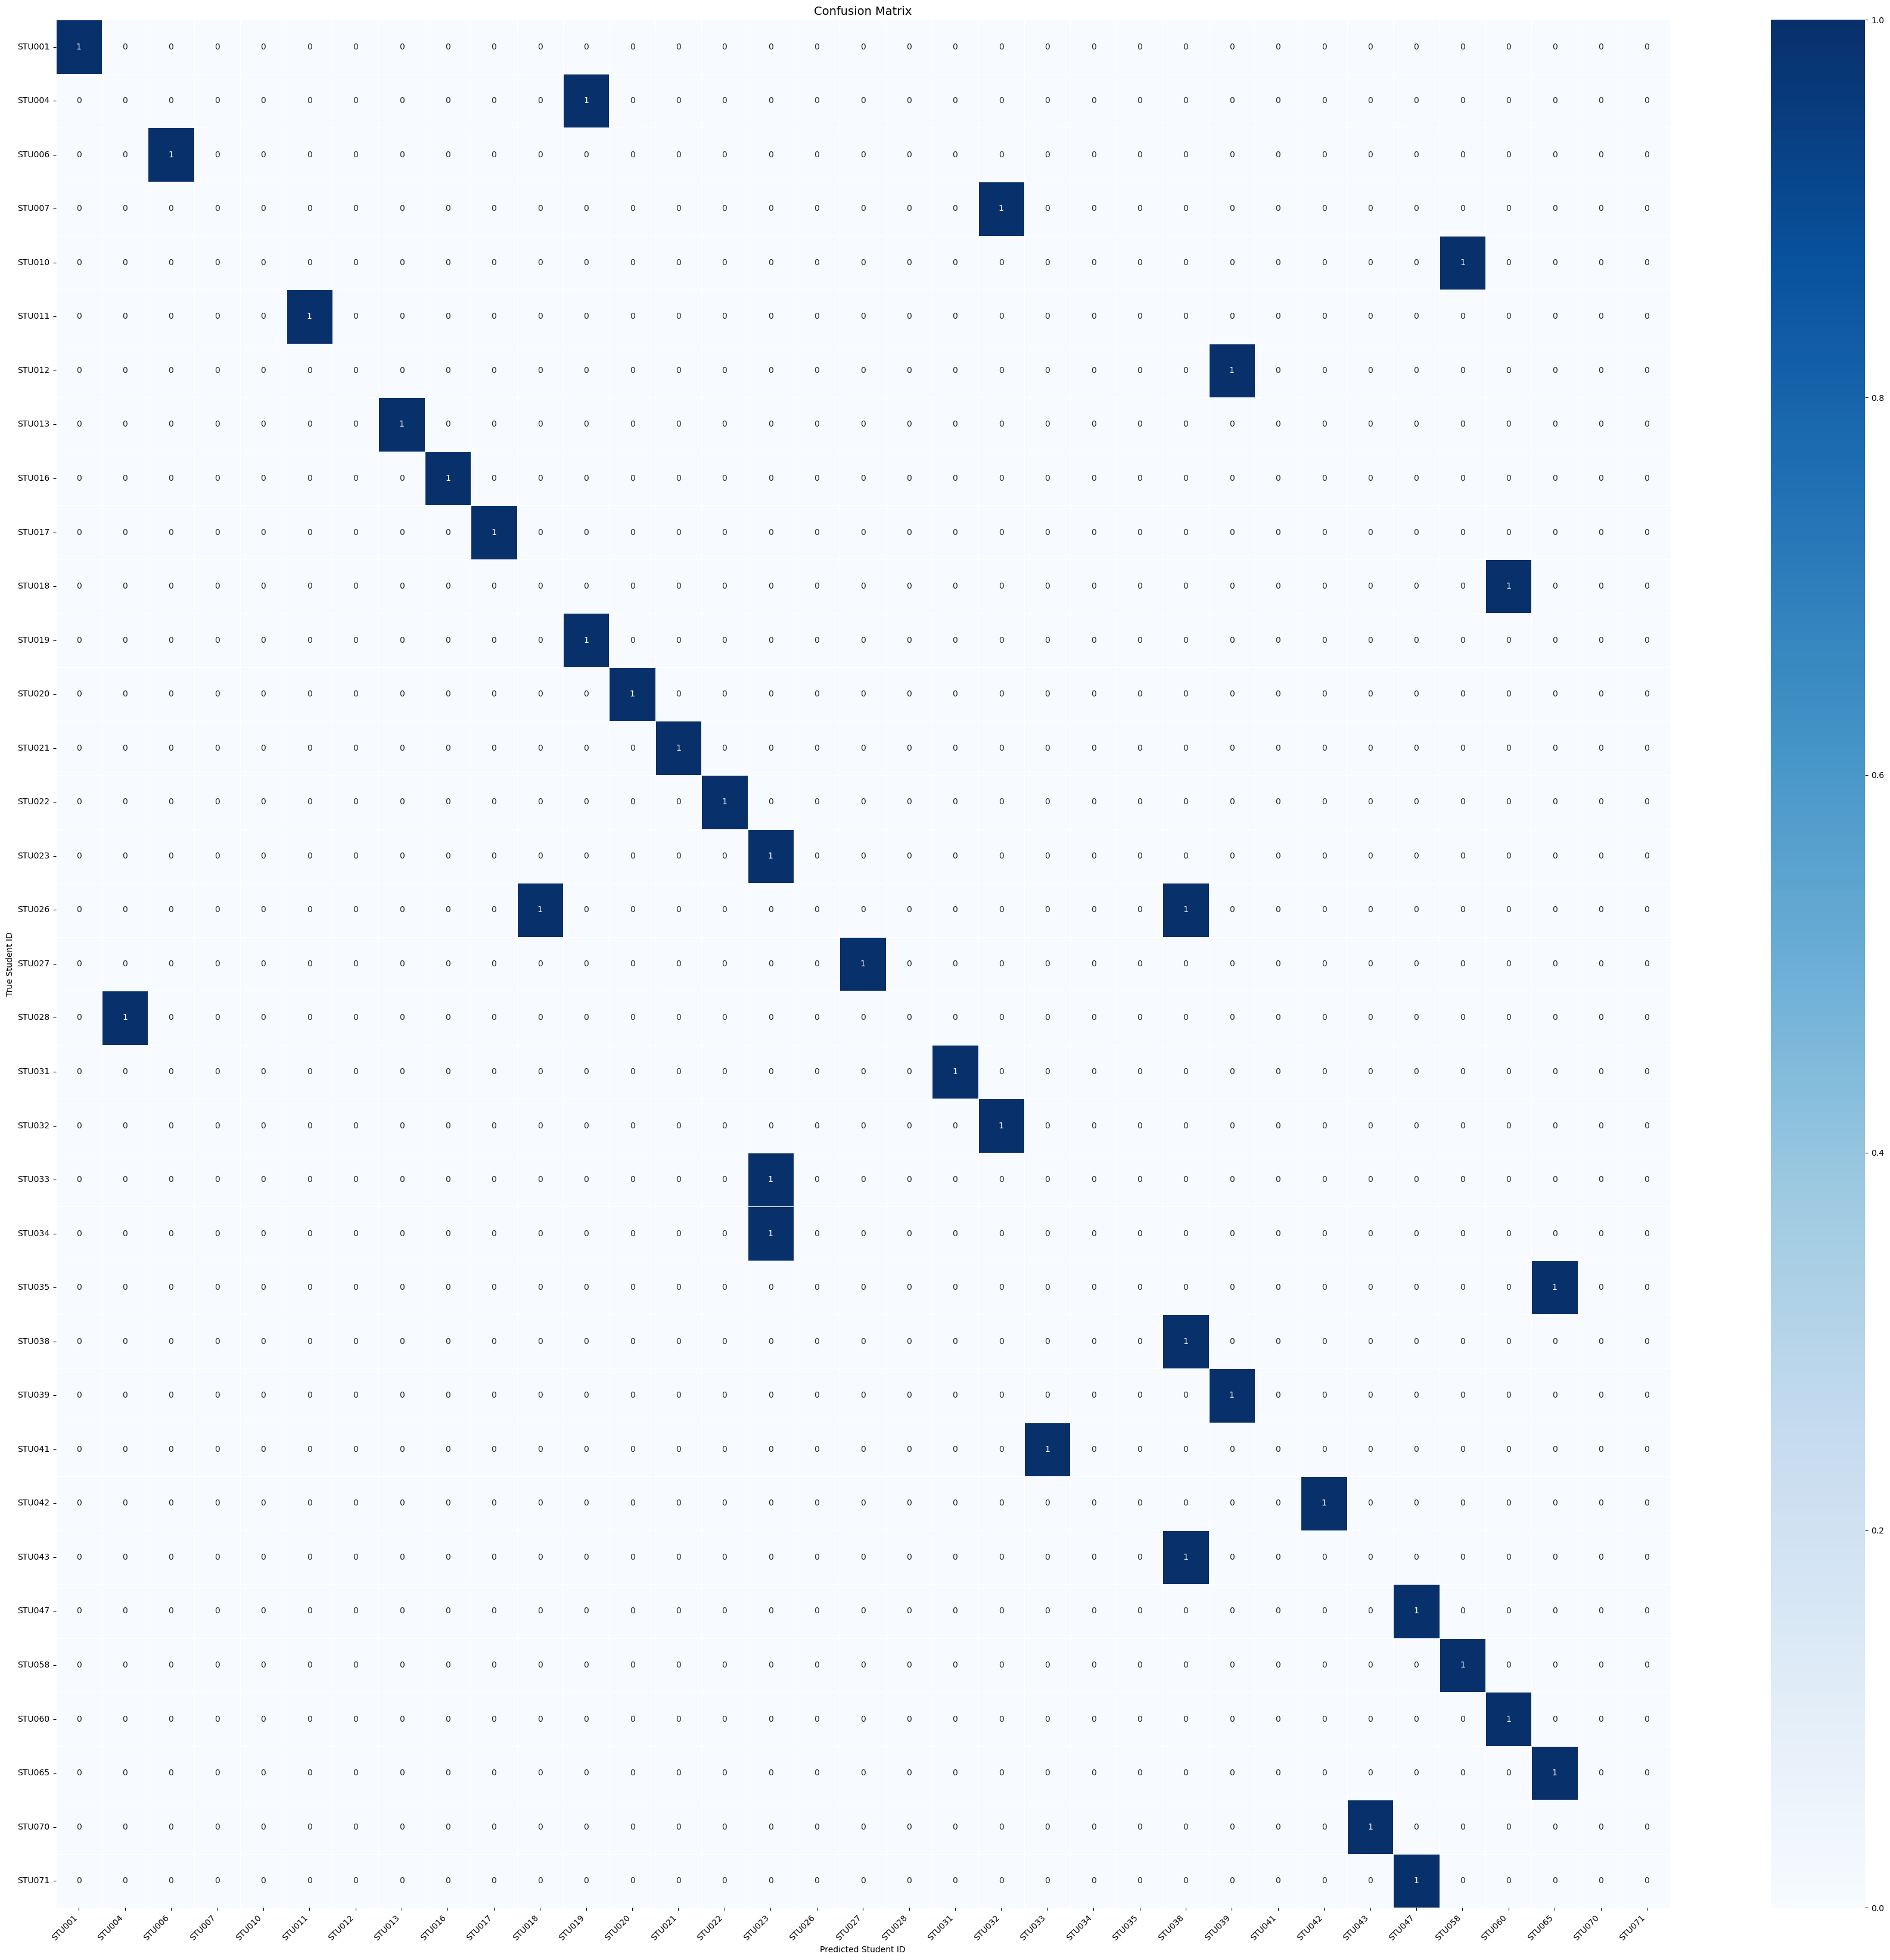

Correctly classified: 21 out of 36


In [25]:
cm = confusion_matrix(y_test_encoded, y_pred_encoded)

plt.figure(figsize=(max(8, NUM_CLASSES), max(6, NUM_CLASSES - 2)))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    linewidths=0.5
)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Student ID')
plt.ylabel('True Student ID')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

correct = np.trace(cm)
total   = cm.sum()
print(f'Correctly classified: {correct} out of {total}')


In [26]:
# Save weights (recommended PyTorch approach)
torch.save(model.state_dict(), 'face_recognition_model.pth')
print('Model weights saved as face_recognition_model.pth')

# Also save model architecture info so we can reconstruct it later
model_config = {
    'num_classes'  : NUM_CLASSES,
    'img_size'     : IMG_SIZE,
}
with open('model_config.pkl', 'wb') as f:
    pickle.dump(model_config, f)
print('Model config saved as model_config.pkl')


Model weights saved as face_recognition_model.pth
Model config saved as model_config.pkl


In [27]:
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print('Label encoder saved as label_encoder.pkl')
print('Classes saved:', list(le.classes_))


Label encoder saved as label_encoder.pkl
Classes saved: [np.str_('STU001'), np.str_('STU004'), np.str_('STU006'), np.str_('STU007'), np.str_('STU010'), np.str_('STU011'), np.str_('STU012'), np.str_('STU013'), np.str_('STU016'), np.str_('STU017'), np.str_('STU018'), np.str_('STU019'), np.str_('STU020'), np.str_('STU021'), np.str_('STU022'), np.str_('STU023'), np.str_('STU026'), np.str_('STU027'), np.str_('STU028'), np.str_('STU031'), np.str_('STU032'), np.str_('STU033'), np.str_('STU034'), np.str_('STU035'), np.str_('STU038'), np.str_('STU039'), np.str_('STU041'), np.str_('STU042'), np.str_('STU043'), np.str_('STU047'), np.str_('STU058'), np.str_('STU060'), np.str_('STU065'), np.str_('STU070'), np.str_('STU071')]


In [28]:
import pickle
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

# ── Load config ──────────────────────────────────────────────────────────────
with open('model_config.pkl', 'rb') as f:
    model_config = pickle.load(f)

NUM_CLASSES = model_config['num_classes']
IMG_SIZE    = model_config['img_size']

# ── Re-create model architecture ─────────────────────────────────────────────
# You must define FaceCNN exactly as in Step 7 before running this cell.
loaded_model = FaceCNN(num_classes=NUM_CLASSES)
loaded_model.load_state_dict(torch.load('face_recognition_model.pth',
                                         map_location='cpu'))
loaded_model.eval()
print('Model loaded successfully.')
print('Expected input: (N, 3, 128, 128) — batch of RGB tensors')

# ── Load label encoder ───────────────────────────────────────────────────────
with open('label_encoder.pkl', 'rb') as f:
    loaded_le = pickle.load(f)

print('Label encoder loaded.')
print('Known student IDs:', list(loaded_le.classes_))


Model loaded successfully.
Expected input: (N, 3, 128, 128) — batch of RGB tensors
Label encoder loaded.
Known student IDs: [np.str_('STU001'), np.str_('STU004'), np.str_('STU006'), np.str_('STU007'), np.str_('STU010'), np.str_('STU011'), np.str_('STU012'), np.str_('STU013'), np.str_('STU016'), np.str_('STU017'), np.str_('STU018'), np.str_('STU019'), np.str_('STU020'), np.str_('STU021'), np.str_('STU022'), np.str_('STU023'), np.str_('STU026'), np.str_('STU027'), np.str_('STU028'), np.str_('STU031'), np.str_('STU032'), np.str_('STU033'), np.str_('STU034'), np.str_('STU035'), np.str_('STU038'), np.str_('STU039'), np.str_('STU041'), np.str_('STU042'), np.str_('STU043'), np.str_('STU047'), np.str_('STU058'), np.str_('STU060'), np.str_('STU065'), np.str_('STU070'), np.str_('STU071')]


In [29]:
def predict_student(image_path, model, label_encoder, img_size=(128, 128)):
    """
    Load a face image from disk, preprocess it,
    and return the predicted student ID with confidence.
    """
    img = cv2.imread(image_path)
    if img is None:
        print(f'ERROR: Cannot read image at {image_path}')
        return None, None

    # Preprocess: resize, convert colors, normalise
    img_resized = cv2.resize(img, img_size, interpolation=cv2.INTER_AREA)
    img_rgb     = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    img_pil     = Image.fromarray(img_rgb)

    preprocess = transforms.Compose([
        transforms.ToTensor(),   # Converts to (C, H, W) float32 in [0, 1]
    ])
    img_tensor = preprocess(img_pil).unsqueeze(0)  # Add batch dim: (1, C, H, W)

    # Run prediction
    with torch.no_grad():
        outputs = model(img_tensor)
        probs   = torch.softmax(outputs, dim=1)[0]
        predicted_class = probs.argmax().item()
        confidence      = probs[predicted_class].item()

    student_id = label_encoder.inverse_transform([predicted_class])[0]
    return student_id, confidence


In [30]:
# Replace this path with the path to any test face image
TEST_IMAGE_PATH = 'faces/STU001/img1.jpg'

student_id, confidence = predict_student(
    TEST_IMAGE_PATH, loaded_model, loaded_le
)

if student_id is not None:
    print(f'Predicted Student ID: {student_id}')
    print(f'Confidence          : {confidence * 100:.2f}%')

    img     = cv2.imread(TEST_IMAGE_PATH)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(f'Prediction: {student_id}  |  Confidence: {confidence*100:.1f}%')
    plt.axis('off')
    plt.show()


ERROR: Cannot read image at faces/STU001/img1.jpg


In [31]:
from sklearn.metrics import accuracy_score

loaded_model.eval()
all_preds_loaded = []
all_true_loaded  = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = loaded_model(images)
        _, preds = torch.max(outputs, 1)
        all_preds_loaded.extend(preds.numpy())
        all_true_loaded.extend(labels.numpy())

loaded_acc = accuracy_score(all_true_loaded, all_preds_loaded)
print(f'Loaded model test accuracy: {loaded_acc * 100:.2f}%')
print('Save and load successful!' if loaded_acc > 0 else 'Something went wrong.')


Loaded model test accuracy: 58.33%
Save and load successful!


C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
